# Data Mining Project: Customer Churn Analysis

**COURSE:** VERİ MADENCİLİĞİ (AIC510)

**INSTRUCTOR:** DR.YILDIZ KARADAYI

**NAME:** SHEKINAH MANYI ACHIDI

**STUDENT ID:** 25221001023

In [33]:
# Importing essential libraries for Data Mining
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning and Evaluation libraries
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Loading the dataset directly from a reliable source
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

print("Dataset loaded successfully. Shape:", df.shape)
df.head()

Dataset loaded successfully. Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 1. Data Cleaning
In this section, we handle missing values and inconsistencies. 
- The `TotalCharges` column was imported as an 'object' type but should be numeric.
- We will identify and remove any null values created during conversion.
- We drop `customerID` as it is a unique identifier that does not contribute to pattern recognition.

In [34]:
# Convert TotalCharges to numeric, turning empty strings into 'NaN'
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Identify missing values
missing_count = df.isnull().sum().sum()
print(f"Number of missing values identified: {missing_count}")

# Remove rows with missing values (justification: they represent a tiny fraction of the data)
df.dropna(inplace=True)

# Drop unnecessary columns (Feature Selection)
df.drop('customerID', axis=1, inplace=True)

print("Data cleaning complete. New shape:", df.shape)

Number of missing values identified: 11
Data cleaning complete. New shape: (7032, 20)


## 2. Exploratory Data Analysis (EDA)
We start by examining the distribution of our target variable: **Churn**. 
This helps us understand if the dataset is balanced or imbalanced.

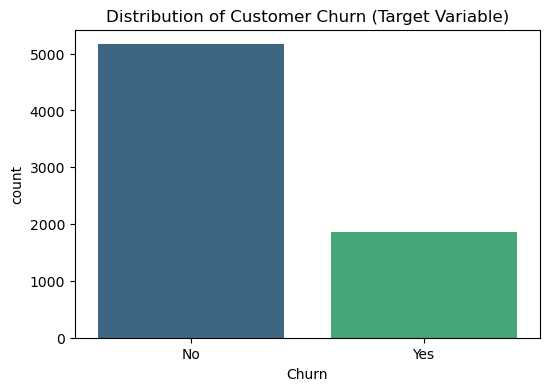

       SeniorCitizen       tenure  MonthlyCharges  TotalCharges
count    7032.000000  7032.000000     7032.000000   7032.000000
mean        0.162400    32.421786       64.798208   2283.300441
std         0.368844    24.545260       30.085974   2266.771362
min         0.000000     1.000000       18.250000     18.800000
25%         0.000000     9.000000       35.587500    401.450000
50%         0.000000    29.000000       70.350000   1397.475000
75%         0.000000    55.000000       89.862500   3794.737500
max         1.000000    72.000000      118.750000   8684.800000


In [35]:
# Visualizing the Churn distribution
plt.figure(figsize=(6, 4))
#sns.countplot(x='Churn', data=df, palette='viridis')
sns.countplot(x='Churn', data=df, hue='Churn', palette='viridis', legend=False)
plt.title('Distribution of Customer Churn (Target Variable)')
plt.show()

# Quick statistical summary of numerical features
print(df.describe())

## 3. Correlation Analysis
To understand which numerical features impact Churn, we calculate the correlation matrix. 
- We first convert 'Churn' to a numeric format (1 for Yes, 0 for No).
- We use a heatmap to visualize the relationship between tenure, charges, and churn.

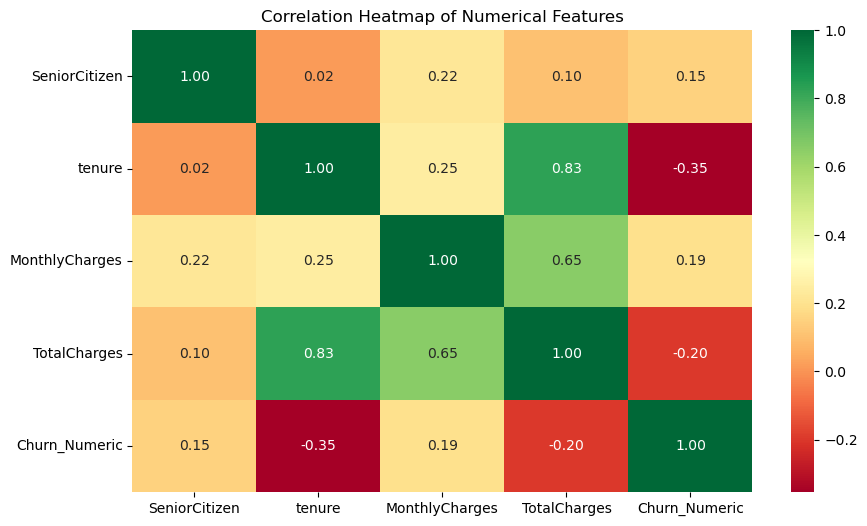

In [36]:
# Convert Churn to numerical for correlation analysis
df['Churn_Numeric'] = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

# Plotting the Correlation Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='RdYlGn', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

# Insight: Check how 'tenure' and 'MonthlyCharges' relate to 'Churn_Numeric'

## 4. Feature Engineering & Data Preparation
Machine learning models require numerical input. Here we:
1. **Label Encoding:** Convert binary categories (Yes/No) into 0 and 1.
2. **One-Hot Encoding:** Convert multi-category columns (e.g., Contract type) into dummy variables.
3. **Scaling:** Normalize numerical features (`tenure`, `MonthlyCharges`) to ensure they are on the same scale, which helps the model converge faster.

In [37]:
# 1. Label Encoding for simple binary columns
le = LabelEncoder()
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_cols:
    df[col] = le.fit_transform(df[col])

# 2. One-Hot Encoding for multi-category columns
# We use drop_first=True to avoid the "dummy variable trap" (multicollinearity)
multi_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 
              'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 
              'Contract', 'PaymentMethod']
df = pd.get_dummies(df, columns=multi_cols, drop_first=True)

# 3. Feature Scaling
scaler = StandardScaler()
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
df[num_cols] = scaler.fit_transform(df[num_cols])

# Finalizing the target and features
X = df.drop(['Churn', 'Churn_Numeric'], axis=1)
y = df['Churn_Numeric']

print(f"Feature Engineering complete. Final feature count: {X.shape[1]}")

Feature Engineering complete. Final feature count: 30


## 5. Model Selection and Implementation
For this project, we selected the **Random Forest Classifier**. 
- **Justification:** Random Forest is an ensemble learning method that is highly effective for classification tasks.It handles both categorical and numerical data well and is resistant to overfitting compared to a single decision tree.
- **Validation:** We use **5-Fold Cross-Validation** to evaluate the model's stability across different subsets of the data.

In [38]:
# Initializing the Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Performing 5-Fold Cross-Validation 
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf_model, X, y, cv=kf)

print(f"Cross-Validation Scores: {cv_scores}")
print(f"Mean Accuracy: {cv_scores.mean():.4f}")
print(f"Standard Deviation: {cv_scores.std():.4f}")

Cross-Validation Scores: [0.78464819 0.79886283 0.76671408 0.79871977 0.79871977]
Mean Accuracy: 0.7895
Standard Deviation: 0.0127


## 6. Model Evaluation
We now train the model on 80% of the data and test it on the remaining 20%. 
We will evaluate the results using:
1. **Accuracy Score:** Overall correctness.
2. **Confusion Matrix:** To see True Positives vs. False Positives.
3. **Classification Report:** To analyze **Precision** and **Recall** which are vital for churn prediction.

In [39]:
# Split the data [cite: 19]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the final model
rf_model.fit(X_train, y_train)

# Make predictions
y_pred = rf_model.predict(X_test)

# Print Evaluation Metrics [cite: 20, 53]
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[935  98]
 [201 173]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.91      0.86      1033
           1       0.64      0.46      0.54       374

    accuracy                           0.79      1407
   macro avg       0.73      0.68      0.70      1407
weighted avg       0.77      0.79      0.78      1407



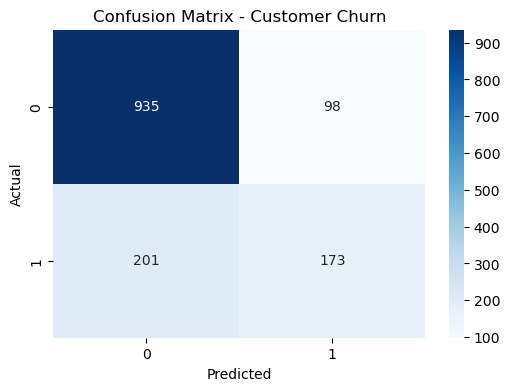

In [40]:
# Visualizing the Confusion Matrix for the Report
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Customer Churn')
plt.show()